In [7]:
from cardroom.briscola.game.env import BriscolaEnv
from cardroom.briscola.game.player import BriscolaPlayer
from cardroom.briscola.agents.random import RandomAgent
from cardroom.briscola.agents.bot import BotAgent
from cardroom.briscola.agents.donatello import DonatelloAgent
from cardroom.briscola.agents.evaluation.evaluate_agent import AgentEvaluator
from cardroom.briscola.agents.evaluation.evaluate_game import DeckMetricsEvaluator

from IPython.display import clear_output

Set up agent to be evaluated and run evalation

In [8]:
agent = DonatelloAgent(simulations = 500, rollout_policy = "bot", cpuct = 1.4)

n_games = 100

Opponent: BotAgent


Playing games... (Donatello wins: 61 | BotAgent wins: 35 | Draws: 4): 100%|██████████| 100/100 [02:19<00:00,  1.39s/it]


Opponent: Donatello200_no_belief


Playing games... (Donatello wins: 55 | Donatello200_no_belief wins: 41 | Draws: 4): 100%|██████████| 100/100 [03:38<00:00,  2.18s/it]

=== Evaluation Recap ===
                        wins  draws  losses  total_games  win_rate    EV  \
opponent                                                                   
BotAgent                  61      4      35          100      0.61  0.26   
Donatello200_no_belief    55      4      41          100      0.55  0.14   

                         p_value  significant  
opponent                                       
BotAgent                0.010346         True  
Donatello200_no_belief  0.184286        False  
=== Flipped-side Analysis ===
                        tot_pairs  won_both  lost_both  won_drew  lost_drew  \
opponent                                                                      
BotAgent                       50        21          7         1          3   
Donatello200_no_belief         50        14          7         2          2   

                        one_each  draw_draw  unknown  
opponent                                              
BotAgent             

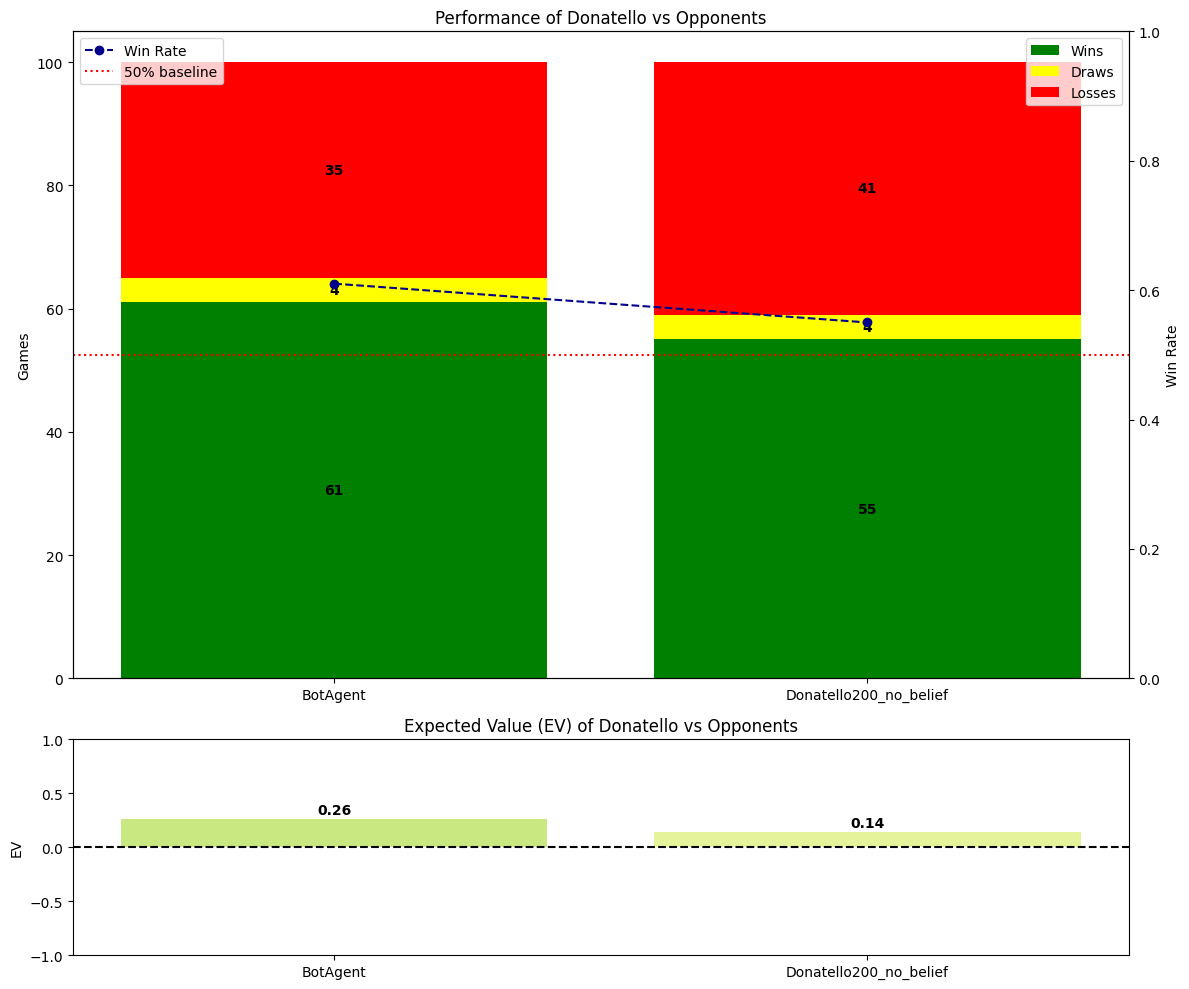

Evaluating endgames...


100%|██████████| 500/500 [00:40<00:00, 12.28it/s]


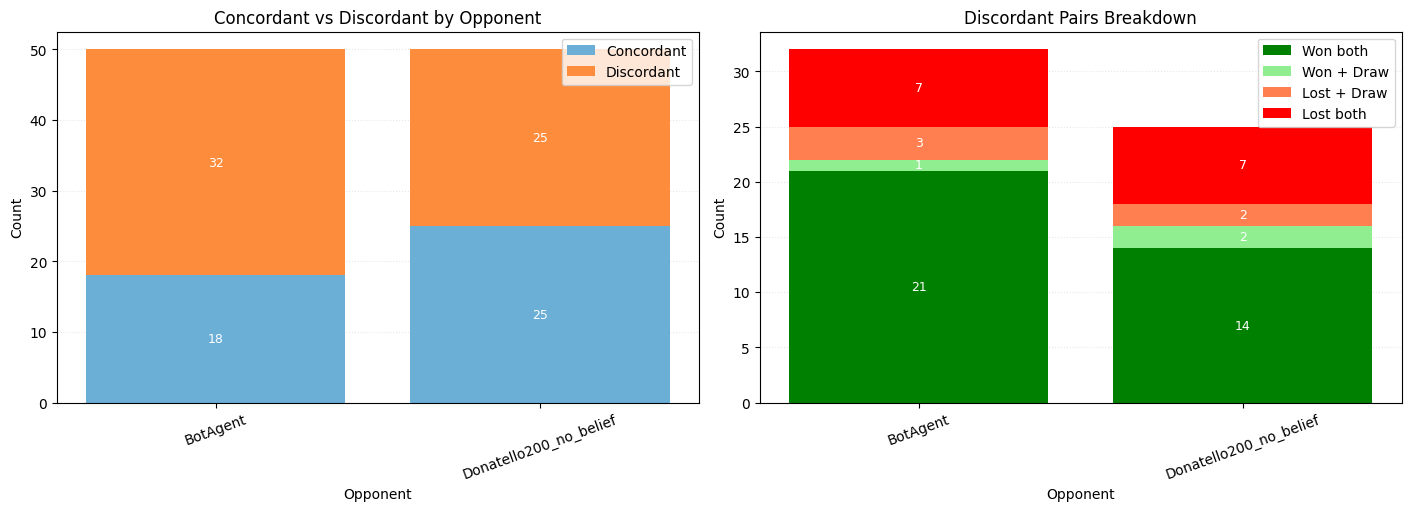

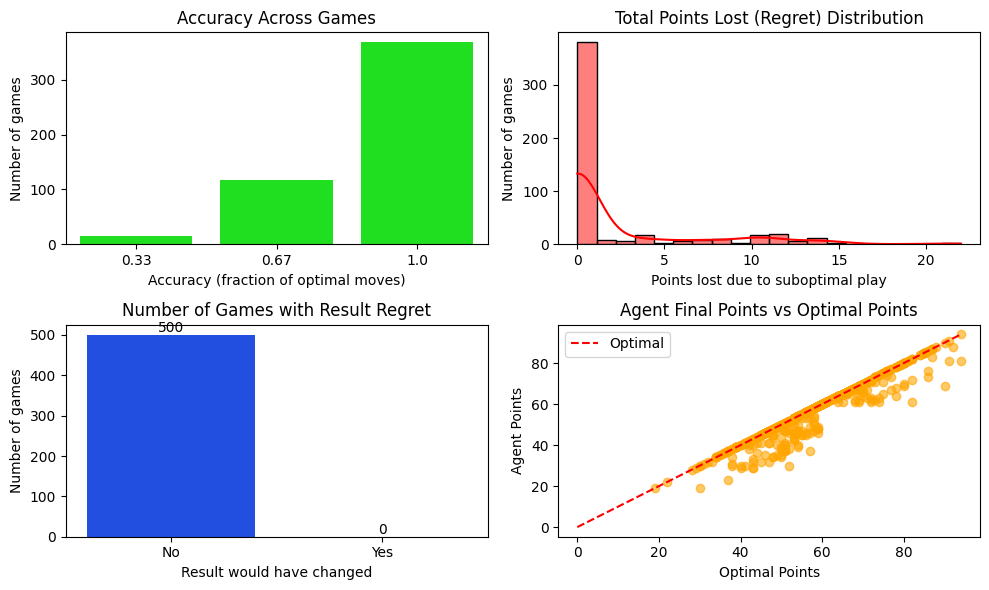

In [9]:
eval = AgentEvaluator(agent, n_games, opponents=[BotAgent(), DonatelloAgent(name="Donatello200_no_belief", simulations=200, use_belief=False)])
eval.run()

Analyze luck factor in the games

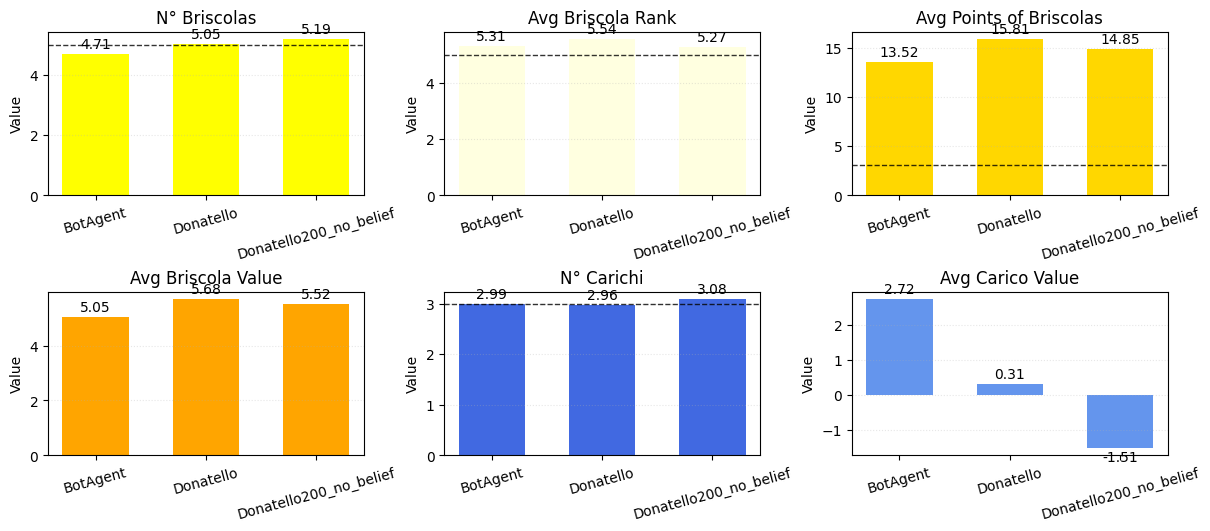

(                   player  n_briscolas  avg_briscola_rank  briscola_points  \
 0                BotAgent         4.71           5.308738           13.520   
 1               Donatello         5.05           5.536952           15.815   
 2  Donatello200_no_belief         5.19           5.271881           14.850   
 
    avg_briscola_value  n_carichi  avg_carico_value  
 0            5.053964      2.990          2.722500  
 1            5.678363      2.965          0.311500  
 2            5.519187      3.080         -1.510167  ,
 <Figure size 1200x520 with 6 Axes>)

In [10]:
res = eval.results
res

states = []
for game in res["final_state"]:
    states.append(game)

deck = DeckMetricsEvaluator(states)

deck.run()

Game 27, pair 13; winner: BotAgent


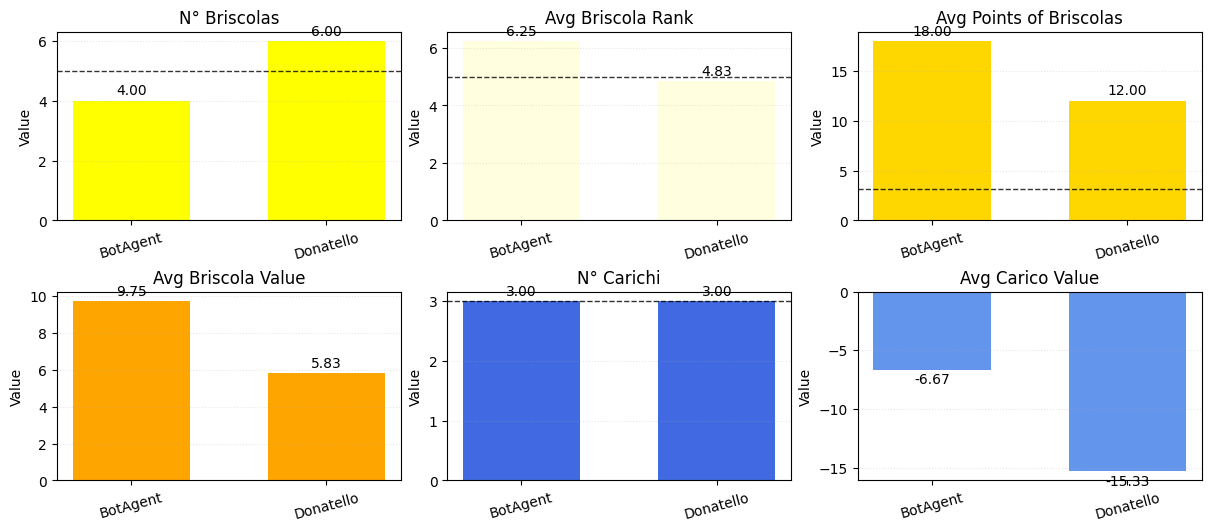

KeyboardInterrupt: Interrupted by user

In [11]:
opp = "BotAgent" # opponent to consider for analysis

for opponent, opp_rows in res.groupby("opponent"):
    if opponent != opp:
        continue
    for pair_id, g in opp_rows.groupby("pair_id"):
        if g["winner"].tolist() == [opp, opp]: # analyze pair where agent lost both games
            for game_idx, row in g.iterrows():
                print(f"Game {game_idx}, pair {row['pair_id']}; winner: {row['winner']}")
                deckeval = DeckMetricsEvaluator([row["final_state"]])
                deckeval.run()
                if input("Show next game? [y/n] ") == "n":
                    break
                else:
                    clear_output(wait=True)